## STEPS for End to end Ml Project Work flows  :
####0. Preprocess + EDA + Feature Selection
####1. Extract input and output cols
####2. Scale the values
####3. Train test split I
####4. Train the model
####5. Evaluate the model/model selection
####6. Deploy the model

In [23]:
import numpy as np
import pandas as pd

In [24]:
df = pd.read_csv('/content/placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [5]:
df.shape

(100, 4)

### Remove Unnamed column from the table (preprocess)

In [26]:
df = df.iloc[:,1:]

In [28]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [30]:
import matplotlib.pyplot as plt

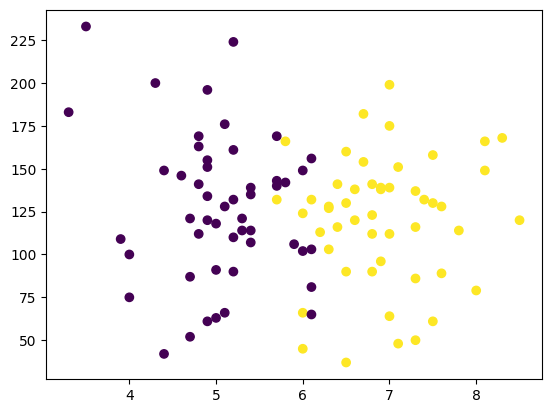

In [31]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [32]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [34]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [36]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [37]:
X_train

,cgpa,iq
45,6.0,66.0
89,4.9,151.0
91,7.5,158.0
26,7.0,199.0
25,5.0,91.0
...,...,...
50,3.5,233.0
1,5.9,106.0
36,5.7,140.0
85,5.8,166.0


In [38]:
y_train

,placement
45,1
89,0
91,1
26,1
25,0
...,...
50,0
1,0
36,0
85,1


In [39]:
X_test

,cgpa,iq
5,7.1,48.0
21,7.1,151.0
9,5.1,66.0
88,4.4,149.0
69,8.5,120.0
86,5.1,128.0
33,6.0,149.0
7,5.0,63.0
95,4.3,200.0
94,4.7,52.0


In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
scaler = StandardScaler()

In [42]:
X_train = scaler.fit_transform(X_train)

In [43]:
X_train

array([[-0.01800706, -1.53486269],
       [-1.00839537,  0.6839014 ],
       [ 1.33252245,  0.86662315],
       [ 0.88234595,  1.93685054],
       [-0.91836007, -0.88228502],
       [ 1.42255775,  0.08352994],
       [-1.27850127,  0.55338587],
       [ 1.15245185, -1.01280055],
       [-1.00839537,  0.24014858],
       [-1.90874838, -0.41242909],
       [-0.73828947, -0.90838812],
       [-1.18846597, -0.09919181],
       [-0.28811296,  0.47507655],
       [-0.19807766,  0.44897344],
       [ 1.33252245, -1.66537822],
       [-1.45857187, -2.16133726],
       [ 0.88234595,  1.31037597],
       [-1.00839537,  1.85854122],
       [ 0.07202824, -1.14331608],
       [ 0.52220474,  0.34456101],
       [ 0.88234595,  0.37066412],
       [-1.00839537, -0.12529491],
       [-1.09843067,  1.15375733],
       [-0.64825417, -0.28191356],
       [ 0.25209884,  0.08352994],
       [-1.81871308, -0.64735705],
       [ 0.25209884,  0.05742684],
       [ 0.52220474, -0.12529491],
       [ 0.70227535,

In [44]:
X_test = scaler.transform(X_test)

In [45]:
X_test

array([[ 0.97238125, -2.00471861],
       [ 0.97238125,  0.6839014 ],
       [-0.82832477, -1.53486269],
       [-1.45857187,  0.63169519],
       [ 2.23287546, -0.12529491],
       [-0.82832477,  0.08352994],
       [-0.01800706,  0.63169519],
       [-0.91836007, -1.61317201],
       [-1.54860717,  1.96295364],
       [-1.18846597, -1.90030619]])

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
clf = LogisticRegression()

##Model Training

In [48]:
clf.fit(X_train,y_train)

LogisticRegression()

In [49]:
y_pred = clf.predict(X_test)

In [50]:
y_test

,placement
5,1
21,1
9,0
88,0
69,1
86,0
33,0
7,0
95,0
94,0


In [51]:
from sklearn.metrics import accuracy_score

In [52]:
accuracy_score(y_test,y_pred)

0.9

In [53]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

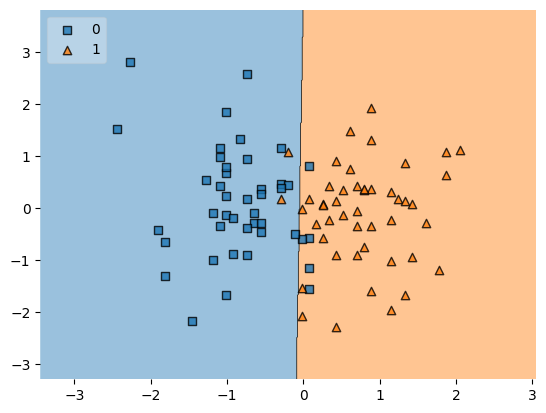

In [54]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

###Model as file to Deploy with Software or Website



In [56]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))